
# Phase 4: Differences in flight bookings by education level


First, we set up the environment with the necessary libraries:

In [1]:
# Libraries for data processing:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None) # To be able to see all columns from the data frames

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, kstest

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the clean csv file as dataframe:
df_master = pd.read_csv("clean-data/merged-master-data-clean.csv")


# **1. Data preparation**

In [3]:
df_phase4 = df_master[['education', 'flights_booked']].copy()
display(df_phase4.head(3))
print(f"The dataframe has {df_phase4.shape[0]} rows and {df_phase4.shape[1]} columns.")


,education,flights_booked
0,Bachelor,3
1,Bachelor,2
2,Bachelor,6


The dataframe has 356685 rows and 2 columns.


# **2. Descriptive analysis**

In [4]:
stats_education = (df_phase4.groupby('education')['flights_booked']).describe()
display(round(stats_education,2))

,count,mean,std,min,25%,50%,75%,max
education,,,,,,,,
Bachelor,223240.0,4.20,5.25,0.0,0.0,1.0,8.0,21.0
College,90013.0,4.20,5.23,0.0,0.0,1.0,8.0,21.0
Doctor,15735.0,4.26,5.27,0.0,0.0,1.0,8.0,21.0
High School or Below,16759.0,4.26,5.27,0.0,0.0,1.0,8.0,21.0
Master,10938.0,4.20,5.22,0.0,0.0,1.0,8.0,21.0


- There is almost no difference between the different education levels. 
- The means are very close, all around 4.2. This sugguest that the customer's education does not influence how many flights they book.
- One important thing to comment is that the mean in all groups is 1, way smaller than the mean. This is because the customers that fly the most are influencing the whole dataset. They are bringing the mean to the right, whereas most of the customers are booking less flights.

- The same can be seen on the graphs below. 
- While the bachelor segment accounts for the highest total volume of bookings due to its large population size, the individual booking behavious is consisent across all education levels. The customer's education level is not a driver of flight boooking frequency, as the mean number of flights is around 4.2 across all groups".
- The equal booking behavious can be seen on the box plot. All have a similar mean (lower) and median (higher) and the same outliers.

In [5]:
mean_flights = round(df_phase4["flights_booked"].mean(),2)
median_flights = round(df_phase4["flights_booked"].median(),2)


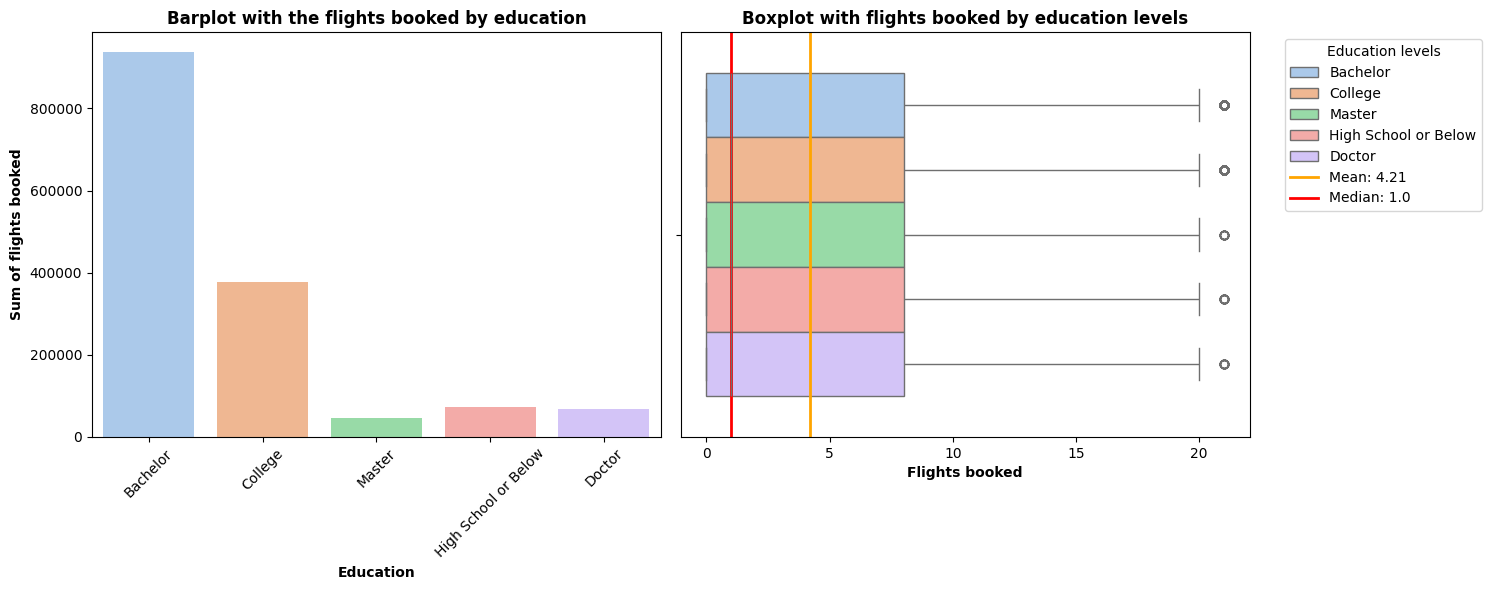

In [8]:
fig, axes = plt.subplots(ncols=2,nrows=1, figsize=(15,6)) 

sns.barplot(data=df_phase4, x="education", y = "flights_booked", ax=axes[0],hue="education",estimator="sum",palette="pastel",errorbar=None); # barplot in position 0. 
axes[0].set_title("Barplot with the flights booked by education",fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_xlabel("Education",fontweight="bold")
axes[0].set_ylabel("Sum of flights booked",fontweight="bold")
sns.boxplot(data=df_phase4, x="flights_booked",ax=axes[1], hue="education",palette="pastel") # boxplot in position 1. 
axes[1].axvline(mean_flights, color = "orange", linestyle = "-", linewidth = 2, label = f"Mean: {mean_flights}")
axes[1].axvline(median_flights, color = "red", linestyle = "-", linewidth = 2, label = f"Median: {median_flights}")
axes[1].legend(title='Education levels', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_title("Boxplot with flights booked by education levels",fontweight="bold")
axes[1].set_xlabel("Flights booked",fontweight="bold")
plt.tight_layout();